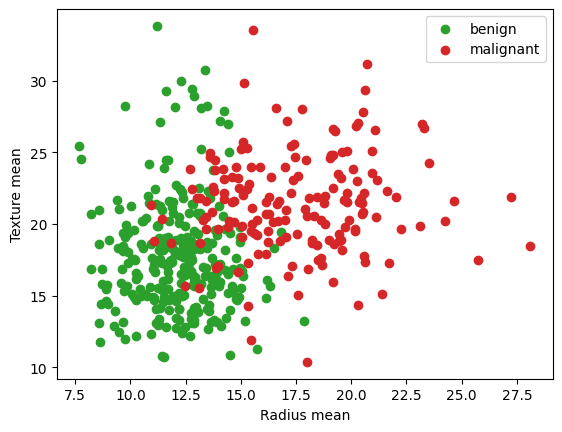

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

path = "C:\\Users\\mdkha\\Desktop\\MY stuff\\python\\ML\\wdbc.data"

df = pd.read_csv(path,sep=",",header = None)
x = df.drop(columns=[0,1]).values
y=(df[1] == "M").astype(int).values

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)

plt.scatter(x_train[y_train == 0,0],x_train[y_train == 0,1],color = "tab:green",label = "benign")
plt.scatter(x_train[y_train == 1,0],x_train[y_train == 1,1],color = "tab:red",label = "malignant")

plt.xlabel("Radius mean")
plt.ylabel("Texture mean")
plt.legend()
plt.show()


In [25]:
def ecu_dis(a,b):
    return np.sqrt(np.sum((b-a)**2))

In [26]:
class KNN:
    def __init__(self,k):
        self.k  = k
    
    def train(self,x,y):
        self.x_train = x
        self.y_train = y

    def predict(self,new_input):
        prediction = [self.predict_class(new_point) for new_point in new_input]
        return prediction
    
    def predict_class(self,new_point):
        distances = [ecu_dis(point,new_point) for point in self.x_train]

        k_nearest_index = np.argsort(distances)[:self.k]
        k_nearest_label = [self.y_train[i] for i in k_nearest_index]

        most_common = Counter(k_nearest_label).most_common(1)[0][0]
        return most_common


accuracy is 92.98245614035088


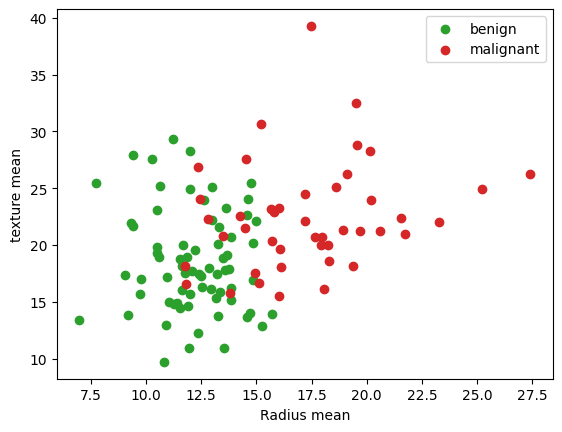

In [31]:
knn = KNN(7)
knn.train(x_train,y_train)
predictions = knn.predict(x_test)
accuracy = np.mean(predictions == y_test) * 100
print(f"accuracy is {accuracy}")   
plt.scatter(x_test[y_test == 0,0],x_test[y_test == 0,1],color = "tab:green",label = "benign")
plt.scatter(x_test[y_test == 1,0],x_test[y_test == 1,1],color = "tab:red",label = "malignant")
plt.xlabel("Radius mean")
plt.ylabel("texture mean")
plt.legend()
plt.show()